In [5]:
# ============================================================
# FRAUD DETECTION SYSTEM - PHASE 1: SETUP & EDA
# Dataset: IEEE-CIS Fraud Detection (Kaggle)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# ─────────────────────────────────────────
# Make sure train_transaction.csv and train_identity.csv
# are inside your data/ folder
# Download from: https://www.kaggle.com/c/ieee-fraud-detection/data
# ─────────────────────────────────────────

train_transaction = pd.read_csv('../data/train_transaction.csv')
train_identity    = pd.read_csv('../data/train_identity.csv')

# Merge on TransactionID (left join keeps all transactions)
df = pd.merge(train_transaction, train_identity,
              on='TransactionID', how='left')

# Free memory
del train_transaction, train_identity

print(f"✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape}")
print(f"📋 Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

(590540, 394)
✅ Dataset loaded successfully!
📊 Shape: (590540, 434)
📋 Rows: 590,540 | Columns: 434


In [7]:
print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
df.head()

FIRST 5 ROWS


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,...,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.500,W,13926,NaN,150.000,discover,142.000,credit,315.000,87.000,19.000,NaN,NaN,NaN,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.000,W,2755,404.000,150.000,mastercard,102.000,credit,325.000,87.000,NaN,NaN,gmail.com,NaN,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.000,W,4663,490.000,150.000,visa,166.000,debit,330.000,87.000,287.000,NaN,outlook.com,NaN,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.000,W,18132,567.000,150.000,mastercard,117.000,debit,476.000,87.000,NaN,NaN,yahoo.com,NaN,2.000,5.000,0.000,0.000,0.000,4.000,0.000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.000,H,4497,514.000,150.000,mastercard,102.000,credit,420.000,87.000,NaN,NaN,gmail.com,NaN,1.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000,...,NotFound,166.000,NaN,542.000,144.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.000,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [ ]:
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info(verbose=False)

print("\n")
print("=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
df.describe()
    

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


BASIC STATISTICS


,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,dist2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,...,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_13,id_14,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,590540.000,590540.000,590540.000,590540.000,590540.000,581607.000,588975.000,586281.000,524834.000,524834.000,238269.000,37627.000,590540.000,590540.000,590540.000,590540.000,590540.000,590540.000,590540.000,590540.000,590540.000,590540.000,590540.000,590540.000,590540.000,...,82351.000,82351.000,144233.000,140872.000,66324.000,66324.000,136865.000,136865.000,5155.000,5155.000,74926.000,74926.000,140978.000,127320.000,80044.000,139369.000,45113.000,139318.000,139261.000,5159.000,5169.000,4747.000,5132.000,5163.000,77586.000
mean,3282269.500,0.035,7372311.310,135.027,9898.735,362.555,153.195,199.279,290.734,86.801,118.502,231.855,14.092,15.270,0.006,4.092,5.572,9.071,2.848,5.145,4.480,5.240,10.242,4.076,32.540,...,151.161,100.701,-10.171,174716.585,0.060,-0.059,1.616,-6.699,13.285,-38.600,0.091,-0.301,99.745,48.053,-344.507,189.451,14.237,353.128,403.883,368.270,16.003,12.801,329.609,149.070,26.509
std,170474.358,0.184,4617223.647,239.163,4901.170,157.793,11.336,41.244,101.741,2.691,371.872,529.053,133.569,154.669,0.151,68.848,25.787,71.508,61.727,95.379,16.675,95.581,94.336,86.666,129.365,...,1095.034,814.947,14.348,159651.817,0.598,0.701,5.250,16.491,11.384,26.085,0.984,2.789,1.128,11.775,93.696,30.375,1.561,141.095,152.160,198.847,6.898,2.372,97.461,32.102,3.738
min,2987000.000,0.000,86400.000,0.251,1000.000,100.000,100.000,100.000,100.000,10.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,-100.000,1.000,-13.000,-28.000,-72.000,-100.000,-46.000,-100.000,-36.000,-100.000,90.000,10.000,-660.000,100.000,10.000,100.000,100.000,100.000,10.000,11.000,100.000,100.000,0.000
25%,3134634.750,0.000,3027057.750,43.321,6019.000,214.000,150.000,166.000,204.000,87.000,3.000,7.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,...,0.000,0.000,-10.000,67992.000,0.000,0.000,0.000,-6.000,5.000,-48.000,0.000,0.000,100.000,49.000,-360.000,166.000,13.000,266.000,256.000,252.000,14.000,11.000,321.000,119.000,24.000
50%,3282269.500,0.000,7306527.500,68.769,9678.000,361.000,150.000,226.000,299.000,87.000,8.000,37.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,1.000,0.000,3.000,...,0.000,0.000,-5.000,125800.500,0.000,0.000,0.000,0.000,14.000,-34.000,0.000,0.000,100.000,52.000,-300.000,166.000,15.000,341.000,472.000,252.000,14.000,11.000,321.000,149.000,24.000
75%,3429904.250,0.000,11246620.000,125.000,14184.000,512.000,150.000,226.000,330.000,87.000,24.000,206.000,3.000,3.000,0.000,0.000,1.000,2.000,0.000,0.000,2.000,0.000,2.000,0.000,12.000,...,0.000,0.000,-5.000,228749.000,0.000,0.000,1.000,0.000,22.000,-23.000,0.000,0.000,100.000,52.000,-300.000,225.000,15.000,427.000,533.000,486.500,14.000,15.000,371.000,169.000,32.000
max,3577539.000,1.000,15811131.000,31937.391,18396.000,600.000,231.000,237.000,540.000,102.000,10286.000,11623.000,4685.000,5691.000,26.000,2253.000,349.000,2253.000,2255.000,3331.000,210.000,3257.000,3188.000,3188.000,2918.000,...,104060.000,104060.000,0.000,999595.000,10.000,0.000,52.000,0.000,61.000,0.000,25.000,0.000,100.000,64.000,720.000,229.000,29.000,671.000,661.000,854.000,44.000,26.000,548.000,216.000,32.000


TARGET VARIABLE: isFraud

🔴 Fraudulent Transactions   : 20,663 (3.50%)
🟢 Legitimate Transactions   : 569,877 (96.50%)

⚠️  Class Imbalance Ratio     : 1 : 27


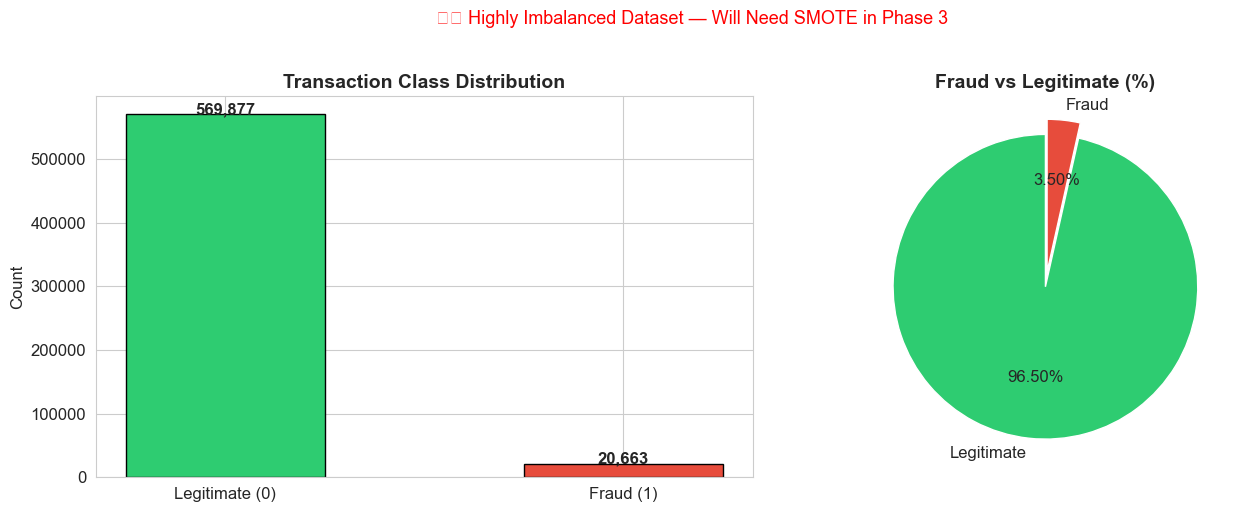

In [ ]:
print("=" * 60)
print("TARGET VARIABLE: isFraud")
print("=" * 60)

fraud_counts = df['isFraud'].value_counts()
fraud_pct    = df['isFraud'].value_counts(normalize=True) * 100

print(f"\n🔴     Fraudulent Transactions   : {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)")
print(f"🟢 Legitimate Transactions   : {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)")
print(f"\n⚠️  Class Imbalance Ratio     : 1 : {int(fraud_counts[0]/fraud_counts[1])}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Legitimate (0)', 'Fraud (1)'],
            fraud_counts.values,
            color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(fraud_counts.values,
            labels=['Legitimate', 'Fraud'],
            colors=colors,
            autopct='%1.2f%%',
            startangle=90,
            explode=(0, 0.1))
axes[1].set_title('Fraud vs Legitimate (%)', fontsize=14, fontweight='bold')

plt.suptitle('⚠️ Highly Imbalanced Dataset — Will Need SMOTE in Phase 3',
             fontsize=13, color='red', y=1.02)
plt.tight_layout()
plt.show()

MISSING VALUE ANALYSIS

Total columns with missing values : 414
Columns with >50% missing          : 214
Columns with >90% missing          : 12

Top 20 columns with most missing values:
       Missing Count  Missing %
id_24         585793     99.196
id_25         585408     99.131
id_07         585385     99.127
id_08         585385     99.127
id_21         585381     99.126
id_26         585377     99.126
id_27         585371     99.125
id_23         585371     99.125
id_22         585371     99.125
dist2         552913     93.628
D7            551623     93.410
id_18         545427     92.361
D13           528588     89.509
D14           528353     89.469
D12           525823     89.041
id_04         524216     88.769
id_03         524216     88.769
D6            517353     87.607
id_33         517251     87.589
id_09         515614     87.312


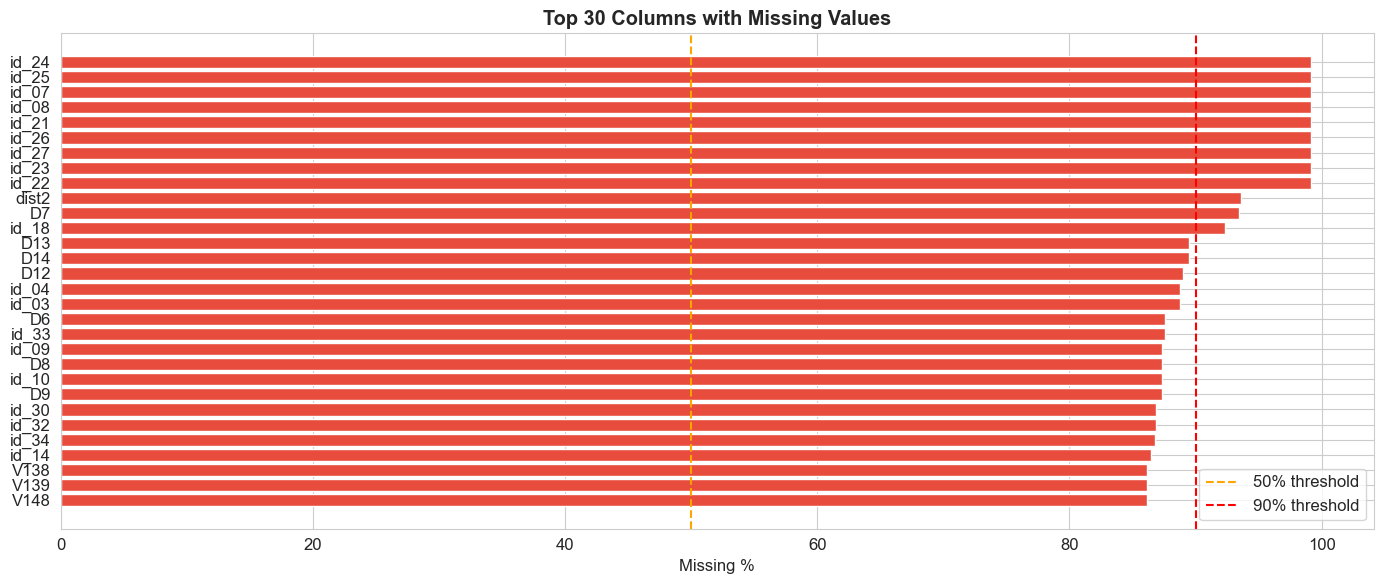

In [14]:
print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

# Calculate missing %
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %':     (df.isnull().sum() / len(df)) * 100
}).sort_values('Missing %', ascending=False)

missing = missing[missing['Missing Count'] > 0]

print(f"\nTotal columns with missing values : {len(missing)}")
print(f"Columns with >50% missing          : {len(missing[missing['Missing %'] > 50])}")
print(f"Columns with >90% missing          : {len(missing[missing['Missing %'] > 90])}")

# Top 20
print("\nTop 20 columns with most missing values:")
print(missing.head(20).to_string())

# Visualize top 30
plt.figure(figsize=(14, 6))
top_missing = missing.head(30)
plt.barh(top_missing.index[::-1],
         top_missing['Missing %'][::-1],
         color='#e74c3c')
plt.axvline(x=50, color='orange', linestyle='--', label='50% threshold')
plt.axvline(x=90, color='red',    linestyle='--', label='90% threshold')
plt.xlabel('Missing %')
plt.title('Top 30 Columns with Missing Values', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
print("=" * 60)
print("FEATURE TYPE BREAKDOWN")
print("=" * 60)

numerical_cols   = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n🔢 Numerical Features  : {len(numerical_cols)}")
print(f"🔤 Categorical Features: {len(categorical_cols)}")
print(f"\n📋 Categorical columns : {categorical_cols}")

FEATURE TYPE BREAKDOWN

🔢 Numerical Features  : 403
🔤 Categorical Features: 31

📋 Categorical columns : ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


TRANSACTION AMOUNT ANALYSIS

Transaction Amount Stats:
             count    mean     std   min    25%    50%     75%       max
isFraud                                                                 
0       569877.000 134.512 239.395 0.251 43.970 68.500 120.000 31937.391
1        20663.000 149.245 232.212 0.292 35.044 75.000 161.000  5191.000


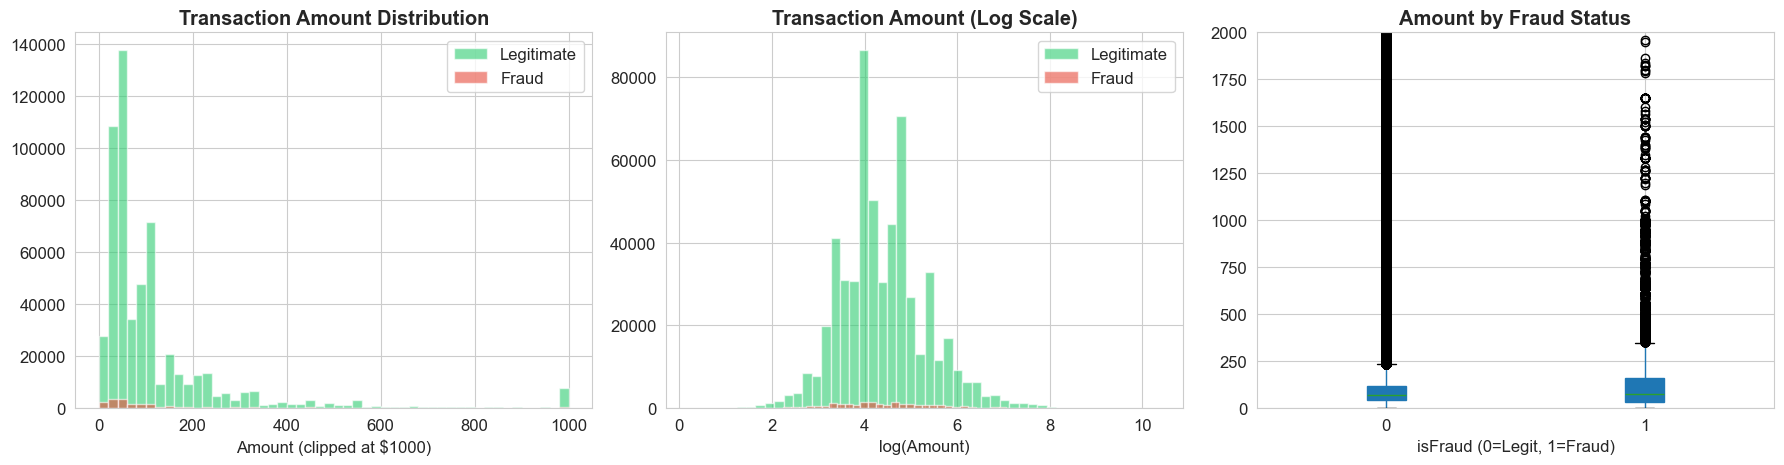

In [16]:
print("=" * 60)
print("TRANSACTION AMOUNT ANALYSIS")
print("=" * 60)

print("\nTransaction Amount Stats:")
print(df.groupby('isFraud')['TransactionAmt'].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution (clipped)
axes[0].hist(df[df['isFraud']==0]['TransactionAmt'].clip(upper=1000),
             bins=50, alpha=0.6, color='#2ecc71', label='Legitimate')
axes[0].hist(df[df['isFraud']==1]['TransactionAmt'].clip(upper=1000),
             bins=50, alpha=0.6, color='#e74c3c', label='Fraud')
axes[0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Amount (clipped at $1000)')
axes[0].legend()

# Log scale
axes[1].hist(np.log1p(df[df['isFraud']==0]['TransactionAmt']),
             bins=50, alpha=0.6, color='#2ecc71', label='Legitimate')
axes[1].hist(np.log1p(df[df['isFraud']==1]['TransactionAmt']),
             bins=50, alpha=0.6, color='#e74c3c', label='Fraud')
axes[1].set_title('Transaction Amount (Log Scale)', fontweight='bold')
axes[1].set_xlabel('log(Amount)')
axes[1].legend()

# Boxplot
df.boxplot(column='TransactionAmt', by='isFraud', ax=axes[2],
           patch_artist=True)
axes[2].set_title('Amount by Fraud Status', fontweight='bold')
axes[2].set_xlabel('isFraud (0=Legit, 1=Fraud)')
axes[2].set_ylim(0, 2000)

plt.suptitle('')
plt.tight_layout()
plt.show()

TIME-BASED FRAUD PATTERN ANALYSIS


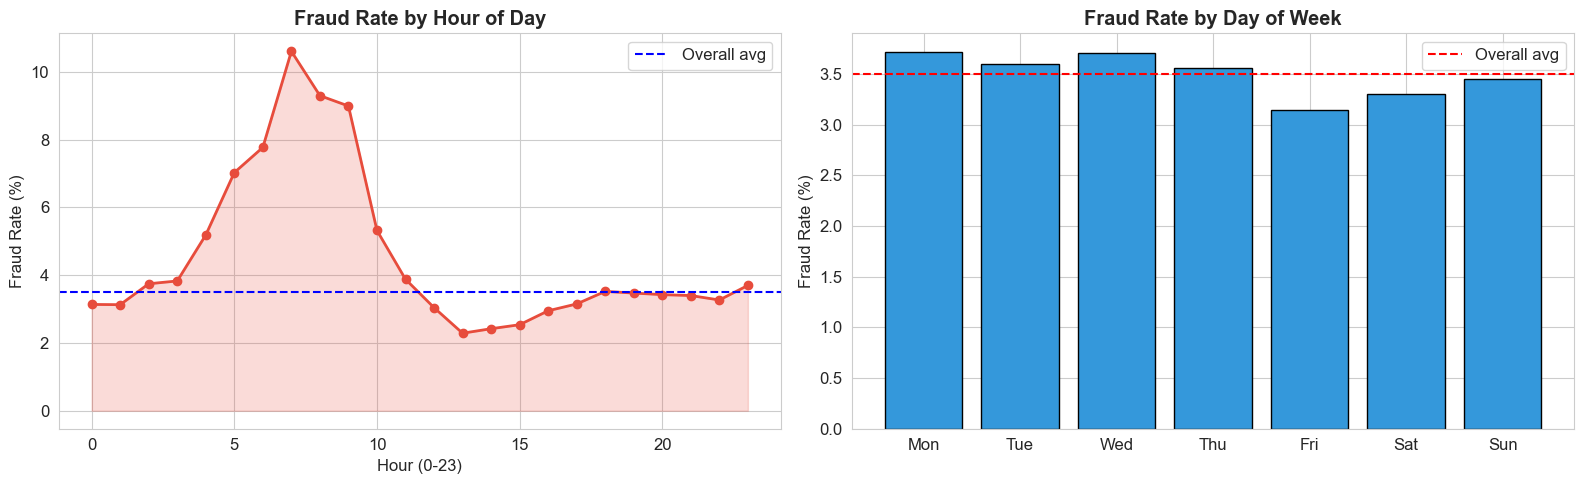

In [17]:
print("=" * 60)
print("TIME-BASED FRAUD PATTERN ANALYSIS")
print("=" * 60)

# TransactionDT = seconds from a reference point
df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day']  = (df['TransactionDT'] // (3600 * 24)) % 7


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Fraud rate by hour
hourly_fraud = df.groupby('hour')['isFraud'].mean() * 100
axes[0].plot(hourly_fraud.index, hourly_fraud.values,
             marker='o', color='#e74c3c', linewidth=2)
axes[0].fill_between(hourly_fraud.index, hourly_fraud.values,
                     alpha=0.2, color='#e74c3c')
axes[0].set_title('Fraud Rate by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].axhline(y=df['isFraud'].mean()*100,
                color='blue', linestyle='--', label='Overall avg')
axes[0].legend()

# Fraud rate by day
daily_fraud = df.groupby('day')['isFraud'].mean() * 100
days_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[1].bar(range(7), daily_fraud.values, color='#3498db', edgecolor='black')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days_labels)
axes[1].set_title('Fraud Rate by Day of Week', fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].axhline(y=df['isFraud'].mean()*100,
                color='red', linestyle='--', label='Overall avg')
axes[1].legend()

plt.tight_layout()
plt.show()

CATEGORICAL FEATURE ANALYSIS


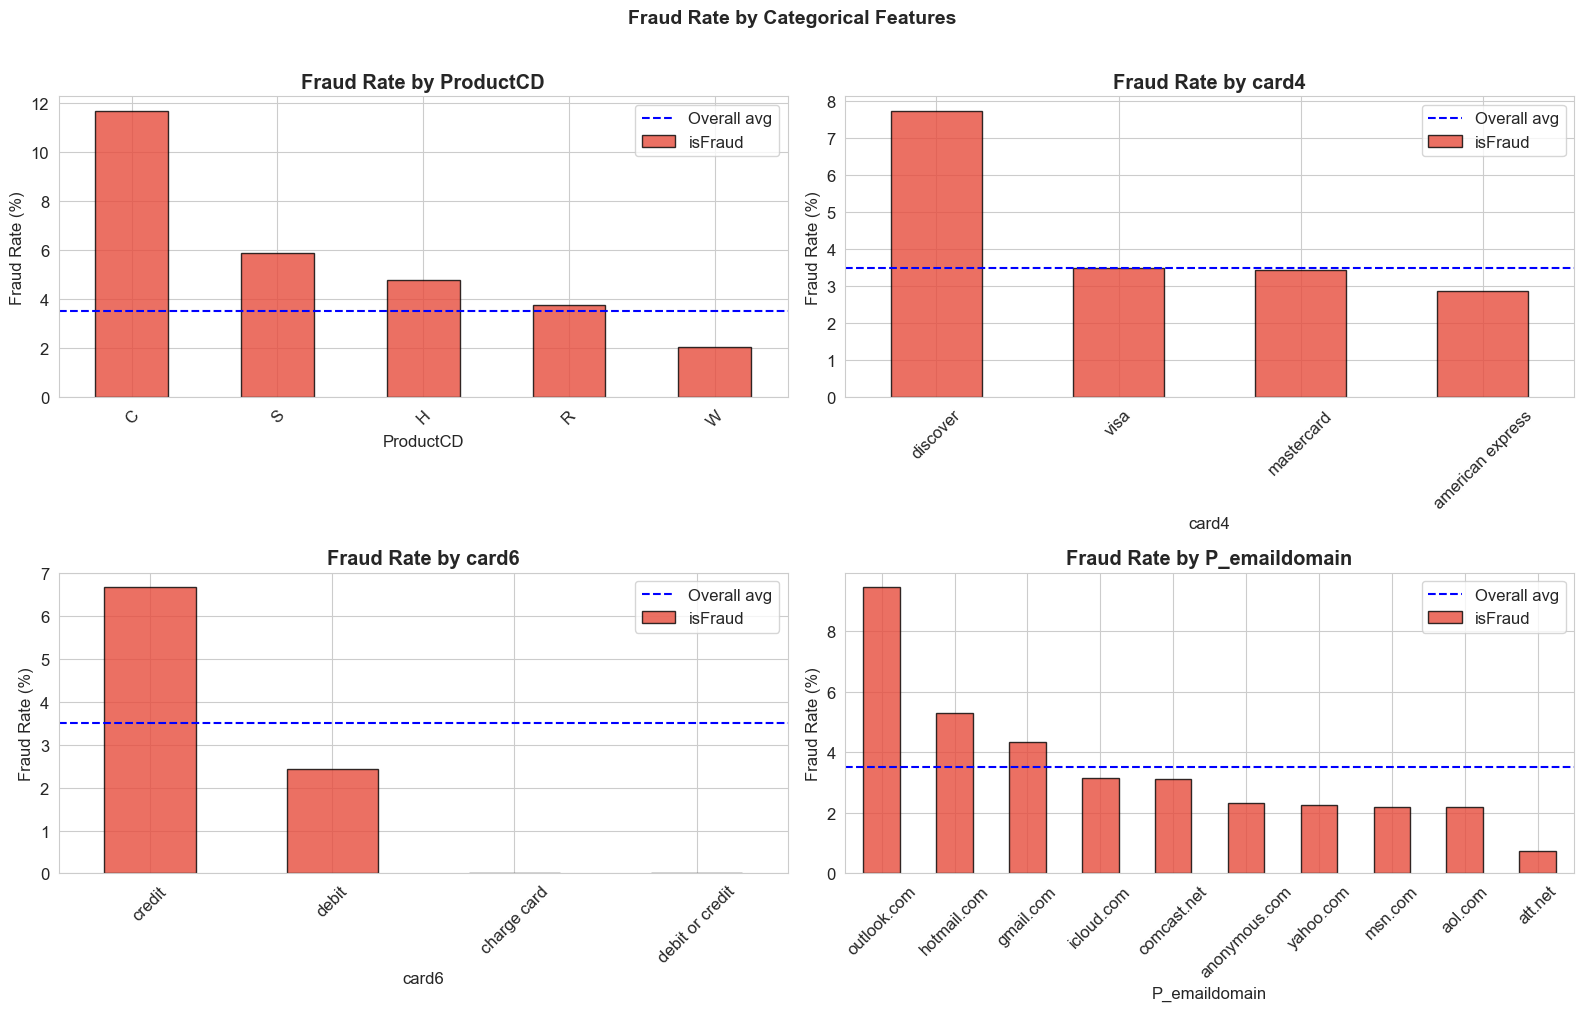

In [18]:
print("=" * 60)
print("CATEGORICAL FEATURE ANALYSIS")
print("=" * 60)

cat_cols_to_plot = ['ProductCD', 'card4', 'card6', 'P_emaildomain']
cat_cols_to_plot = [c for c in cat_cols_to_plot if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_to_plot):
    # Only plot top 10 categories for readability
    top_cats = df[col].value_counts().head(10).index
    subset = df[df[col].isin(top_cats)]
    fraud_rate = subset.groupby(col)['isFraud'].mean().sort_values(ascending=False) * 100
    fraud_rate.plot(kind='bar', ax=axes[i],
                    color='#e74c3c', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Fraud Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Fraud Rate (%)')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(y=df['isFraud'].mean()*100,
                    color='blue', linestyle='--', label='Overall avg')
    axes[i].legend()

plt.suptitle('Fraud Rate by Categorical Features', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

CORRELATION WITH TARGET (isFraud)

Top 20 features most correlated with isFraud:
V257   0.383
V246   0.367
V244   0.364
V242   0.361
V201   0.328
V200   0.319
V189   0.308
V188   0.304
V258   0.297
V45    0.282
V158   0.278
V156   0.276
V149   0.273
V228   0.269
V44    0.260
V86    0.252
V87    0.252
V170   0.250
V147   0.243
V52    0.239


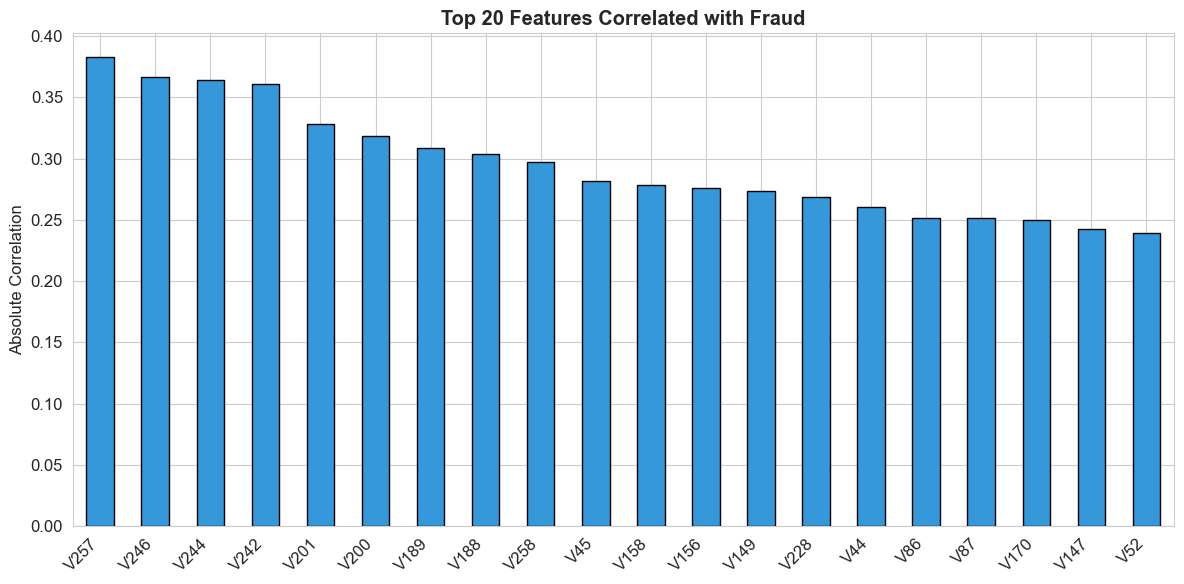

In [19]:
print("=" * 60)
print("CORRELATION WITH TARGET (isFraud)")
print("=" * 60)

# Top correlated numerical features with target
corr_with_target = (df[numerical_cols]
                    .corr()['isFraud']
                    .abs()
                    .sort_values(ascending=False)
                    .drop('isFraud')
                    .head(20))

print("\nTop 20 features most correlated with isFraud:")
print(corr_with_target.to_string())

plt.figure(figsize=(12, 6))
corr_with_target.plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('Top 20 Features Correlated with Fraud', fontweight='bold')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()